Step 1: Generating a realistic DA 3.0 ERG waveform...
Step 2: Saving waveform to 'sample_erg_da3.csv'...
✓ CSV file created successfully!
Step 3: Loading the CSV file...
✓ Loaded 601 time points
Step 4: Measuring a-wave and b-wave parameters...
Step 5: Generating clinical report plot...
✓ Plot saved as 'chapter1_sample_erg.png'


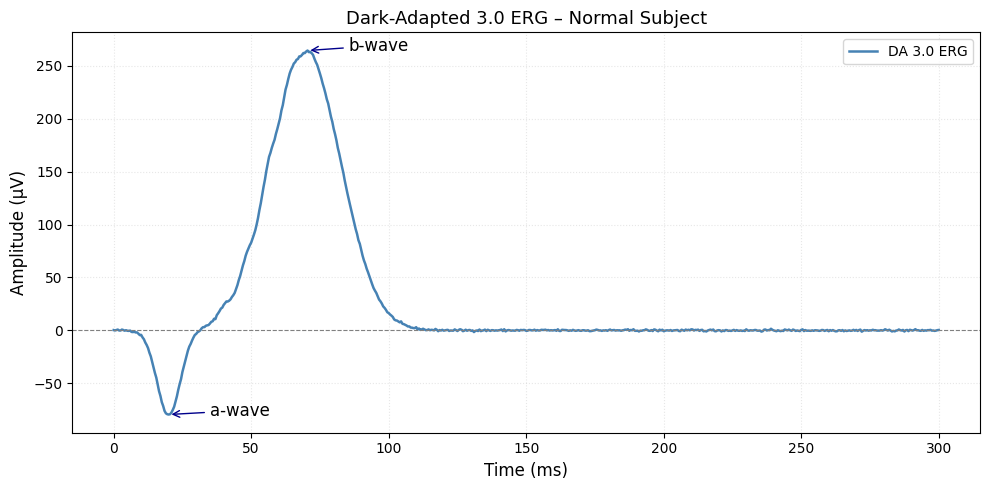


CLINICAL ERG REPORT
Protocol:        Dark-Adapted 3.0 (DA 3.0)
Electrode:       Simulated (contact lens equivalent)
------------------------------------------------------------
a-wave amplitude:     -79.5 µV
a-wave implicit time: 20.0 ms
------------------------------------------------------------
b-wave amplitude:     344.0 µV
b-wave implicit time: 70.5 ms
------------------------------------------------------------
b/a amplitude ratio:  4.33
✓ Interpretation: Normal waveform (b-wave > a-wave)

✓ Analysis complete! The CSV file can now be used with any ERG software.


In [7]:
# -*- coding: utf-8 -*-
"""
ERG Chapter 1: Complete Standalone Code for Clinicians
This code creates a realistic sample ERG waveform, saves it as a CSV file,
then loads and analyses it just like a real clinical recording.

NO prior programming experience required – each step is explained.
"""

# Import required libraries (these must be installed once)
import numpy as np          # For mathematical operations
import matplotlib.pyplot as plt  # For plotting graphs

# ============================================================================
# STEP 1: GENERATE A REALISTIC SAMPLE ERG WAVEFORM
# ============================================================================
# Since clinicians may not have a real CSV file, we create one
# that mimics a normal Dark-Adapted 3.0 (DA 3.0) ERG recording.

print("Step 1: Generating a realistic DA 3.0 ERG waveform...")

# Time vector: from 0 to 300 milliseconds, sampled every 0.5 ms
# This creates 601 time points (0, 0.5, 1.0, ..., 300 ms)
time_ms = np.arange(0, 300.5, 0.5)

# Create an empty amplitude array filled with zeros
amplitude = np.zeros_like(time_ms)

# The a-wave: negative deflection starting around 10 ms, trough at ~20 ms
# Mathematical model: a Gaussian-like negative peak
a_wave_time = 20  # milliseconds to trough
a_wave_amp = -80  # microvolts (typical for normal DA 3.0)
a_wave_width = 6  # width parameter

amplitude += a_wave_amp * np.exp(-((time_ms - a_wave_time) / a_wave_width) ** 2)

# The b-wave: positive deflection, trough-to-peak from a-wave trough
# Peak occurs around 50 ms after the a-wave trough (total ~70 ms)
b_wave_time = 70   # milliseconds to peak
b_wave_amp = 260   # microvolts (b-wave amplitude from a-wave trough)
b_wave_width = 18

amplitude += b_wave_amp * np.exp(-((time_ms - b_wave_time) / b_wave_width) ** 2)

# Add oscillatory potentials (OPs): small ripples on the b-wave ascending limb
# These are generated by amacrine cells in the inner retina
op_times = [40, 48, 56, 64, 72]  # milliseconds
op_amps = [8, 12, 15, 10, 5]     # microvolts
op_width = 3

for t, a in zip(op_times, op_amps):
    amplitude += a * np.exp(-((time_ms - t) / op_width) ** 2)

# Add a tiny amount of random noise to simulate real recording (0.5 µV)
np.random.seed(42)  # Fixed seed so results are reproducible
amplitude += np.random.normal(0, 0.5, len(time_ms))

# ============================================================================
# STEP 2: SAVE THE GENERATED WAVEFORM AS A CSV FILE
# ============================================================================
# CSV (Comma-Separated Values) is a standard format that Excel, Python, and
# ERG systems can all read. First row is headers, then one row per time point.

print("Step 2: Saving waveform to 'sample_erg_da3.csv'...")

# Stack time and amplitude side-by-side into a 2-column array
data_to_save = np.column_stack((time_ms, amplitude))

# Save with headers
header = "Time_ms, Amplitude_uV"
np.savetxt('sample_erg_da3.csv', data_to_save, delimiter=',',
           header=header, comments='', fmt='%.3f')

print("✓ CSV file created successfully!")

# ============================================================================
# STEP 3: LOAD THE CSV FILE (just like a real clinical recording)
# ============================================================================
# This mimics exactly what would happen if you recorded a real patient

print("Step 3: Loading the CSV file...")

# Load the data, skipping the header row (row 0)
data = np.loadtxt('sample_erg_da3.csv', delimiter=',', skiprows=1)
time_ms_loaded = data[:, 0]   # Column 0: time in milliseconds
amplitude_loaded = data[:, 1]  # Column 1: amplitude in microvolts

print(f"✓ Loaded {len(time_ms_loaded)} time points")

# ============================================================================
# STEP 4: MEASURE a-WAVE AND b-WAVE (CLINICAL MEASUREMENT)
# ============================================================================
# This is exactly how an ERG technician or automated system measures the waveform

print("Step 4: Measuring a-wave and b-wave parameters...")

# Find a-wave: the most negative (minimum) amplitude point
a_idx = np.argmin(amplitude_loaded)
a_amplitude = amplitude_loaded[a_idx]      # in microvolts
a_implicit_time = time_ms_loaded[a_idx]    # in milliseconds

# Find b-wave: the maximum amplitude AFTER the a-wave trough
# This ensures we don't accidentally pick something before the a-wave
after_a = amplitude_loaded[a_idx:]          # Take everything from a-wave onward
b_offset = np.argmax(after_a)               # Position of peak relative to a_idx
b_idx = a_idx + b_offset                    # Absolute index
b_peak_amplitude = amplitude_loaded[b_idx]  # Peak value in microvolts

# b-wave amplitude is measured from a-wave trough to b-wave peak (clinical standard)
b_amplitude = b_peak_amplitude - a_amplitude
b_implicit_time = time_ms_loaded[b_idx]

# ============================================================================
# STEP 5: CREATE THE CLINICAL REPORT PLOT
# ============================================================================
# This visualization matches what a clinician would see on an ERG system

print("Step 5: Generating clinical report plot...")

fig, ax = plt.subplots(figsize=(10, 5))

# Plot the waveform in a clinical colour (steel blue)
ax.plot(time_ms_loaded, amplitude_loaded, color='steelblue',
        linewidth=1.8, label='DA 3.0 ERG')

# Draw a horizontal line at zero (baseline)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')

# Annotate a-wave with an arrow pointing to the trough
ax.annotate('a-wave',
            xy=(a_implicit_time, a_amplitude),           # Point to on the graph
            xytext=(a_implicit_time + 15, a_amplitude - 1),  # Text position
            arrowprops=dict(arrowstyle='->', color='darkblue'),
            fontsize=12)

# Annotate b-wave with an arrow pointing to the peak
ax.annotate('b-wave',
            xy=(b_implicit_time, b_peak_amplitude),
            xytext=(b_implicit_time + 15, b_peak_amplitude + 0),
            arrowprops=dict(arrowstyle='->', color='darkblue'),
            fontsize=12)

# Add axis labels and title (clinical standard formatting)
ax.set_xlabel('Time (ms)', fontsize=12)
ax.set_ylabel('Amplitude (µV)', fontsize=12)
ax.set_title('Dark-Adapted 3.0 ERG – Normal Subject', fontsize=13)
ax.legend(loc='upper right')

# Add a subtle grid for easier reading
ax.grid(True, linestyle=':', alpha=0.3)

# Adjust layout so nothing gets cut off
plt.tight_layout()

# Save the figure as an image file (for use in reports)
plt.savefig('chapter1_sample_erg.png', dpi=150)
print("✓ Plot saved as 'chapter1_sample_erg.png'")

# Display the plot on screen
plt.show()

# ============================================================================
# STEP 6: PRINT THE CLINICAL REPORT (TEXT OUTPUT)
# ============================================================================
# This mimics what an ERG machine would output in a clinical report

print("\n" + "="*60)
print("CLINICAL ERG REPORT")
print("="*60)
print(f"Protocol:        Dark-Adapted 3.0 (DA 3.0)")
print(f"Electrode:       Simulated (contact lens equivalent)")
print("-"*60)
print(f"a-wave amplitude:     {a_amplitude:.1f} µV")
print(f"a-wave implicit time: {a_implicit_time:.1f} ms")
print("-"*60)
print(f"b-wave amplitude:     {b_amplitude:.1f} µV")
print(f"b-wave implicit time: {b_implicit_time:.1f} ms")
print("-"*60)
print(f"b/a amplitude ratio:  {b_amplitude / abs(a_amplitude):.2f}")
print("="*60)

# Clinical interpretation note
if b_amplitude / abs(a_amplitude) > 1.5:
    print("✓ Interpretation: Normal waveform (b-wave > a-wave)")
else:
    print("⚠ Interpretation: Reduced b/a ratio – consider inner retinal pathology")

print("\n✓ Analysis complete! The CSV file can now be used with any ERG software.")